In [1]:
# If you already have these (recent versions), you can skip.
# In Windows notebooks, prefer %pip over !pip.
%pip install -q "transformers>=4.41.0" "datasets>=2.18.0" evaluate sacrebleu sentencepiece accelerate



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -q bert-score sentence-transformers


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Check disk usage of directories and files in /content
!du -sh /content/*

zsh:1: no matches found: /content/*


In [4]:
from sklearn.metrics import f1_score
from bert_score import score as bertscore
from sentence_transformers import SentenceTransformer
import os
import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer, set_seed
)
from transformers import EarlyStoppingCallback
import evaluate

# Reproducibility
SEED = 42
set_seed(SEED)

# Model choice: multilingual, robust for Telugu
MODEL_NAME = "ai4bharat/IndicBART" # you can switch to "ai4bharat/indicbart-v2" if you prefer
OUTPUT_DIR = "te_qa_supervised_mt5"

# Task: MODEL 2 — Telugu question ONLY → Telugu answer
MAX_SRC_LEN = 256
MAX_TGT_LEN = 64
BATCH_SIZE  = 8          # reduce if RAM is tight
EPOCHS      = 35
LR          = 2e-4

/Users/xk84vl/Documents/Repos/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/xk84vl/Documents/Repos/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# TyDi XOR RC; we’ll keep only Telugu examples where answer_inlang is present
ds = load_dataset("coastalcph/tydi_xor_rc")

def keep_te_with_inlang(x):
    return (x.get("lang") == "te") and (x.get("answer_inlang") not in (None, "")) and (x.get("question") not in (None, ""))

ds_te = {
    "train": ds["train"].filter(keep_te_with_inlang),
    "validation": ds["validation"].filter(keep_te_with_inlang),
}
print("Telugu sizes (train/val):", len(ds_te["train"]), len(ds_te["validation"]))


Filter: 100%|██████████| 3011/3011 [00:00<00:00, 276564.68 examples/s]

Telugu sizes (train/val): 50 100


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


In [7]:
%pip install -q rouge_score


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")

def compute_metrics(eval_preds):
    predictions, labels = eval_preds

    # Decode model outputs and labels
    # Filter out -100 from labels before decoding
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id) # Replace -100 with pad_token_id for decoding if necessary, or just filter. Filtering might be safer.
    # Let's try filtering out -100 completely instead of replacing with pad_token_id
    decoded_labels = []
    for label_seq in labels:
        # Filter out -100 and decode
        valid_label_ids = label_seq[label_seq != -100]
        decoded_labels.append(tokenizer.decode(valid_label_ids, skip_special_tokens=True))

    pred_texts = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    label_texts = decoded_labels


    # Compute BLEU (requires references as list of lists)
    # Ensure references are list of lists
    bleu_score = bleu.compute(
        predictions=pred_texts,
        references=[[ref] for ref in label_texts]
    )["score"]

    # Compute ROUGE
    rouge_result = rouge.compute(predictions=pred_texts, references=label_texts)

    # Compute Exact Match (strict match of entire strings)
    exact_match = sum(p.strip() == l.strip() for p, l in zip(pred_texts, label_texts)) / len(pred_texts)

    return {
        "exact_match": exact_match,
        "bleu": bleu_score,
        "rougeL": rouge_result["rougeL"]
    }

args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    predict_with_generate=True,           # generate during eval (teacher forcing loss + generation metric)
    generation_max_length=MAX_TGT_LEN,
    eval_strategy="epoch",
    save_strategy="best",
    load_best_model_at_end=True,
    metric_for_best_model="eval_bleu", # Corrected here
    greater_is_better=True,
    logging_strategy="steps",
    logging_steps=1,
    report_to="none",
    fp16=torch.cuda.is_available(),       # safe: only on GPU
    # Remove pin_memory=True if no GPU is available
    # pin_memory=torch.cuda.is_available() # This is the default value and should be fine.
    # To explicitly silence the warning when no GPU is present, set it to False:
    dataloader_pin_memory=False if not torch.cuda.is_available() else True,
)

In [9]:
def preprocess(batch):
    """
    Preprocesses a batch of data for instruction tuning.
    Converts Telugu Q/A pairs into instruction-tuned format and tokenizes both source and target.
    """
    questions = batch["question"]
    answers = batch["answer_inlang"]

    # Build instruction-formatted Telugu prompts
    sources = [build_input(q) for q in questions]
    # Tokenize input (the full instruction prompt)
    model_inputs = tokenizer(
        sources,
        max_length=MAX_SRC_LEN,
        truncation=True,
        padding="max_length"
    )

    # Tokenize target (the Telugu answers)
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            answers,
            max_length=MAX_TGT_LEN,
            truncation=True,
            padding="max_length"
        )

    # Replace pad tokens with -100 in the labels (so they don't affect loss)
    labels_ids = [
        [(token if token != tokenizer.pad_token_id else -100) for token in label]
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels_ids
    return model_inputs

In [10]:
# Modify the build_input function for instruction tuning format.
def build_input(q_te: str) -> str:
    return (
        "ఈ క్రింది ప్రశ్నకు సరైన సమాధానాన్ని తెలుగులో సంక్షిప్తంగా ఇవ్వండి.\n"
        f"ప్రశ్న: {q_te}\n"
        "సమాధానం:"
    )

# Verify the updated function with a sample.
sample_q = "తెలంగాణ రాష్ట్ర రాజధాని ఏది?"
print(build_input(sample_q))

ఈ క్రింది ప్రశ్నకు సరైన సమాధానాన్ని తెలుగులో సంక్షిప్తంగా ఇవ్వండి.
ప్రశ్న: తెలంగాణ రాష్ట్ర రాజధాని ఏది?
సమాధానం:


In [11]:
# Apply the updated preprocess function to the training and validation datasets.
# This step corresponds to the original notebook's data processing step after defining preprocess.
proc_train = ds_te["train"].map(preprocess, batched=True, remove_columns=ds_te["train"].column_names)
proc_val   = ds_te["validation"].map(preprocess, batched=True, remove_columns=ds_te["validation"].column_names)

print("Datasets processed with the updated preprocess function.")

Map:   0%|          | 0/50 [00:00<?, ? examples/s]/Users/xk84vl/Documents/Repos/.venv/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
Map: 100%|██████████| 100/100 [00:00<00:00, 2969.57 examples/s]

Datasets processed with the updated preprocess function.


In [12]:
# Re-initialize the trainer with the updated processed datasets.
# All other arguments remain the same as reviewed in the previous step.
trainer = Seq2SeqTrainer(
    model=model, # Use the existing model loaded previously
    args=args,   # Use the existing training arguments
    train_dataset=proc_train, # Use the processed training dataset
    eval_dataset=proc_val,   # Use the processed validation dataset
    tokenizer=tokenizer, # Use the existing tokenizer
    data_collator=data_collator, # Use the existing data collator
    compute_metrics=compute_metrics, # Use the existing compute_metrics function
    #callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]  # implement early stopping. stops if no improvement in evaluations after 2 epochs

)

/var/folders/rc/g6hbpj9x7fzfptshgk1vqn9m0000gp/T/ipykernel_16546/667754091.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [13]:
# Start the fine-tuning process
print("Starting training...")
trainer.train()
print("Training finished.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 3, 'bos_token_id': 2}.


Starting training...


Epoch,Training Loss,Validation Loss,Exact Match,Bleu,Rougel
1,5.676000,4.957742,0.000000,0.000000,0.000000
2,6.433400,4.602315,0.000000,0.000000,0.000000
3,3.828800,4.262286,0.000000,0.000000,0.000000
4,4.012600,4.129795,0.000000,0.000000,0.000000
5,4.629500,4.008474,0.000000,0.000000,0.000000
6,3.595300,3.961278,0.000000,0.000000,0.000000
7,3.397900,3.761955,0.000000,0.000000,0.000000
8,5.063100,3.658212,0.000000,0.049131,0.000000
9,3.920400,3.608305,0.000000,0.000000,0.000000
10,5.792100,3.463469,0.000000,0.056975,0.000000


Training finished.


In [14]:
# Save the fine-tuned model
print("Saving the fine-tuned model...")
#trainer.save_model(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

Saving the fine-tuned model...
Model saved to te_qa_supervised_mt5


In [15]:
def eval_subset(raw_subset, tag):
    proc = raw_subset.map(preprocess, batched=True, remove_columns=raw_subset.column_names)
    metrics = trainer.evaluate(proc, metric_key_prefix=tag)
    print(tag, metrics)
    return metrics

print("\n Validation (overall Telugu)")
eval_subset(ds_te["validation"], "val_all")
print("test to see if following matches telugu overall:")


print("\n=== Split by answerable flag (for analysis) ===")
val_all = ds["validation"].filter(lambda x: x.get("lang")=="te" and x.get("answer_inlang") not in (None, ""))
val_ans = val_all.filter(lambda x: x.get("answerable") is True)
val_un  = val_all.filter(lambda x: x.get("answerable") is False)
eval_subset(val_all, "val_all")
print("answerable:")
eval_subset(val_ans, "val_ans")
print("unanswerable:")
eval_subset(val_un,  "val_un")



 Validation (overall Telugu)


Map:   0%|          | 0/100 [00:00<?, ? examples/s]/Users/xk84vl/Documents/Repos/.venv/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
Map: 100%|██████████| 100/100 [00:00<00:00, 1684.15 examples/s]


val_all {'val_all_loss': 2.45635724067688, 'val_all_exact_match': 0.01, 'val_all_bleu': 0.1309263405388987, 'val_all_rougeL': 0.01, 'val_all_runtime': 44.9338, 'val_all_samples_per_second': 2.225, 'val_all_steps_per_second': 0.289, 'epoch': 35.0}
test to see if following matches telugu overall:

=== Split by answerable flag (for analysis) ===


Map: 100%|██████████| 100/100 [00:00<00:00, 2110.15 examples/s]


val_all {'val_all_loss': 2.45635724067688, 'val_all_exact_match': 0.01, 'val_all_bleu': 0.1309263405388987, 'val_all_rougeL': 0.01, 'val_all_runtime': 46.2715, 'val_all_samples_per_second': 2.161, 'val_all_steps_per_second': 0.281, 'epoch': 35.0}
answerable:


Map: 100%|██████████| 7/7 [00:00<00:00, 1093.04 examples/s]


val_ans {'val_ans_loss': 3.6504523754119873, 'val_ans_exact_match': 0.0, 'val_ans_bleu': 0.0, 'val_ans_rougeL': 0.0, 'val_ans_runtime': 3.2676, 'val_ans_samples_per_second': 2.142, 'val_ans_steps_per_second': 0.306, 'epoch': 35.0}
unanswerable:


Map: 100%|██████████| 93/93 [00:00<00:00, 2030.04 examples/s]


val_un {'val_un_loss': 2.2925398349761963, 'val_un_exact_match': 0.010752688172043012, 'val_un_bleu': 0.13631175366540743, 'val_un_rougeL': 0.010752688172043012, 'val_un_runtime': 40.8762, 'val_un_samples_per_second': 2.275, 'val_un_steps_per_second': 0.294, 'epoch': 35.0}


{'val_un_loss': 2.2925398349761963,
 'val_un_exact_match': 0.010752688172043012,
 'val_un_bleu': 0.13631175366540743,
 'val_un_rougeL': 0.010752688172043012,
 'val_un_runtime': 40.8762,
 'val_un_samples_per_second': 2.275,
 'val_un_steps_per_second': 0.294,
 'epoch': 35.0}

In [22]:
import evaluate
import numpy as np
import torch
from sentence_transformers import SentenceTransformer, util
from transformers import Seq2SeqTrainer

# ==========================================
# Metric + Model Setup
# ==========================================
embed_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
metric_rouge = evaluate.load("rouge")
metric_bertscore = evaluate.load("bertscore")
metric_bleu = evaluate.load("bleu")

# ===============================
# F1 Score (character-level)
# ===============================
def char_level_f1(pred, ref):
    pred_chars = set(pred.strip())
    ref_chars = set(ref.strip())
    if not pred_chars or not ref_chars:
        return 0.0
    tp = len(pred_chars & ref_chars)
    precision = tp / len(pred_chars)
    recall = tp / len(ref_chars)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

# ==========================================
# Compute Metrics Function
# ==========================================
def compute_metrics2(eval_pred, tokenizer, answerable_flags):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]
        
    if isinstance(predictions, torch.Tensor):
        predictions = torch.argmax(predictions, dim=-1)
        
    predictions = np.clip(predictions, 0, tokenizer.vocab_size - 1)
    preds = tokenizer.batch_decode(predictions, skip_special_tokens=True, clean_up_tokenization_spaces=True)
    
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    refs = tokenizer.batch_decode(labels, skip_special_tokens=True)

    answerable_flags = np.array(answerable_flags, dtype=bool)

    if len(answerable_flags) != len(preds):
        raise ValueError(f"Length mismatch: {len(answerable_flags)} flags vs {len(preds)} predictions")

    # ===============================
    # F1 Score
    # ===============================
    f1_scores = np.array([char_level_f1(p, r) for p, r in zip(preds, refs)])
    f1_overall = float(np.mean(f1_scores))
    f1_answerable = float(np.mean(f1_scores[answerable_flags])) if np.any(answerable_flags) else np.nan
    f1_unanswerable = float(np.mean(f1_scores[~answerable_flags])) if np.any(~answerable_flags) else np.nan

    # ===============================
    # BERTScore
    # ===============================
    bert_scores = metric_bertscore.compute(predictions=preds, references=refs, lang="te")
    bert_f1 = np.array(bert_scores["f1"])

    bert_overall = float(np.mean(bert_f1))
    bert_answerable = float(np.mean(bert_f1[answerable_flags])) if np.any(answerable_flags) else np.nan
    bert_unanswerable = float(np.mean(bert_f1[~answerable_flags])) if np.any(~answerable_flags) else np.nan

    # ===============================
    # Semantic Similarity
    # ===============================
    pred_embeds = embed_model.encode(preds, convert_to_tensor=True)
    ref_embeds = embed_model.encode(refs, convert_to_tensor=True)
    cosine_scores = util.cos_sim(pred_embeds, ref_embeds).diagonal().cpu().numpy()

    semantic_overall = float(np.mean(cosine_scores))
    semantic_answerable = float(np.mean(cosine_scores[answerable_flags])) if np.any(answerable_flags) else np.nan
    semantic_unanswerable = float(np.mean(cosine_scores[~answerable_flags])) if np.any(~answerable_flags) else np.nan

    # ===============================
    # Return all metrics
    # ===============================
    return {
        # F1 Score
        "f1_overall": f1_overall,
        "f1_answerable": f1_answerable,
        "f1_unanswerable": f1_unanswerable,

        # BERTScore
        "bertscore_overall": bert_overall,
        "bertscore_answerable": bert_answerable,
        "bertscore_unanswerable": bert_unanswerable,

        # Semantic Similarity
        "semantic_overall": semantic_overall,
        "semantic_answerable": semantic_answerable,
        "semantic_unanswerable": semantic_unanswerable,
    }

answerable_flags = np.array(val_all["answerable"], dtype=bool)

trainer2 = Seq2SeqTrainer(
    model=model, # Use the existing model loaded previously
    args=args,   # Use the existing training arguments
    train_dataset=proc_train, # Use the processed training dataset
    eval_dataset=proc_val,   # Use the processed validation dataset
    tokenizer=tokenizer, # Use the existing tokenizer
    data_collator=data_collator, # Use the existing data collator
    compute_metrics=lambda eval_pred: compute_metrics2(eval_pred, tokenizer, answerable_flags), # Use the existing compute_metrics function
    #callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]  # implement early stopping. stops if no improvement in evaluations after 2 epochs
)

print(len(val_all))
proc = val_all.map(preprocess, batched=True, remove_columns=val_all.column_names)
trainer2.evaluate(proc)

/var/folders/rc/g6hbpj9x7fzfptshgk1vqn9m0000gp/T/ipykernel_16546/1324185947.py:104: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer2 = Seq2SeqTrainer(


100


{'eval_loss': 2.45635724067688,
 'eval_model_preparation_time': 0.0017,
 'eval_f1_overall': 0.4108415108488391,
 'eval_f1_answerable': 0.12671957671957673,
 'eval_f1_unanswerable': 0.432227032772547,
 'eval_bertscore_overall': 0.6053175827860833,
 'eval_bertscore_answerable': 0.5476888290473393,
 'eval_bertscore_unanswerable': 0.6096552309169564,
 'eval_semantic_overall': 0.5216498374938965,
 'eval_semantic_answerable': 0.43119123578071594,
 'eval_semantic_unanswerable': 0.5284585952758789,
 'eval_runtime': 35.7947,
 'eval_samples_per_second': 2.794,
 'eval_steps_per_second': 0.363}

In [16]:

# Define OUTPUT_DIR here to ensure it's available
OUTPUT_DIR = "te_qa_supervised_mt5"

# Load the fine-tuned model
try:
    fine_tuned_model = AutoModelForSeq2SeqLM.from_pretrained(OUTPUT_DIR)
    print(f"Fine-tuned model loaded successfully from {OUTPUT_DIR}")
    # Move the model to GPU if available
    fine_tuned_model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    print(f"Fine-tuned model moved to: {fine_tuned_model.device}")
except Exception as e:
    print(f"Error loading fine-tuned model from {OUTPUT_DIR}: {e}")
    print("Please ensure the training was completed successfully and the OUTPUT_DIR exists and contains the saved model files.")

Error loading fine-tuned model from te_qa_supervised_mt5: Error no file named pytorch_model.bin, model.safetensors, tf_model.h5, model.ckpt.index or flax_model.msgpack found in directory te_qa_supervised_mt5.
Please ensure the training was completed successfully and the OUTPUT_DIR exists and contains the saved model files.


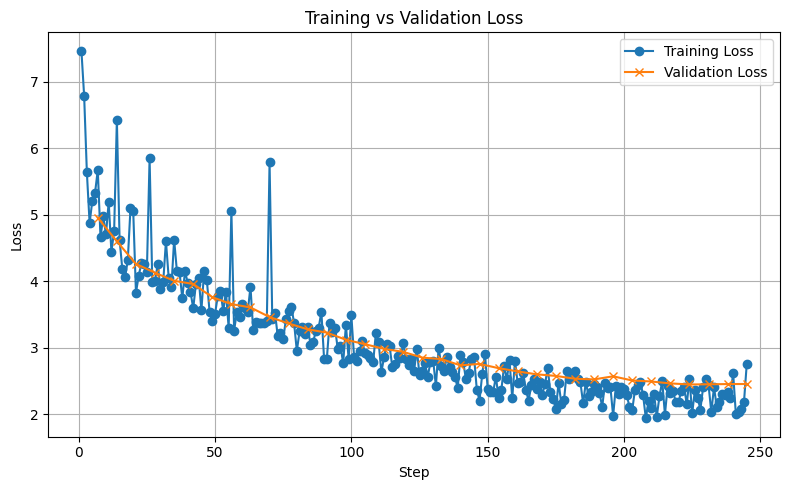

<Figure size 640x480 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt

# Get all training and evaluation logs
logs = trainer.state.log_history

# Extract training and evaluation loss values
train_steps = [entry['step'] for entry in logs if 'loss' in entry and 'step' in entry]
train_losses = [entry['loss'] for entry in logs if 'loss' in entry]

eval_steps = [entry['step'] for entry in logs if 'eval_loss' in entry]
eval_losses = [entry['eval_loss'] for entry in logs if 'eval_loss' in entry]

# Plot both
plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, label="Training Loss", marker='o')
plt.plot(eval_steps, eval_losses, label="Validation Loss", marker='x')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.savefig("training_vs_valid_loss.png")

In [18]:
# Define sample question
sample_q = "మలేరియా వ్యాధి కి మందు కనిపెట్టిన శాస్త్రవేత్త ఎవరు?"

# Define a specific build_input function for inference in this cell
def build_inference_input(q_te: str) -> str:
    """
    Constructs an instruction-style prompt string for a given question for inference.

    Args:
        q_te: The question in Telugu.

    Returns:
        A formatted string following the instruction-style format for inference.
    """
    return (
        "సూచన: ప్రశ్నకు సంక్షిప్తంగా తెలుగులో సమాధానం ఇవ్వండి.\n"
        f"ప్రశ్న: {q_te}\n"
        "సమాధానం:"
    )

# Ensure tokenizer is available (assuming it was loaded in a previous cell)
try:
    tokenizer # Check if tokenizer is defined
except NameError:
    print("Tokenizer is not defined. Please run the cell defining the tokenizer first.")
    # Handle the error appropriately, e.g., exit or load the tokenizer

# Ensure fine_tuned_model is available (assuming it was loaded in a previous cell)
try:
    fine_tuned_model # Check if fine_tuned_model is defined
except NameError:
    print("Fine-tuned model is not defined. Please run the cell loading the fine-tuned model first.")
    # Handle the error appropriately

# Tokenize the input using the inference-specific build_input function
enc = tokenizer(build_inference_input(sample_q), return_tensors="pt").to(fine_tuned_model.device)

# Remove token_type_ids if they are present in the output of the tokenizer
if 'token_type_ids' in enc:
    del enc['token_type_ids']

# Use top-k sampling for generation with the fine-tuned model
# Set do_sample=True and top_k
with torch.no_grad():
    gen_topk = fine_tuned_model.generate(
        **enc,
        max_new_tokens=MAX_TGT_LEN,
        eos_token_id=tokenizer.pad_token_id,
        do_sample=True,
        top_k=50 # You can adjust the value of k
    )
print("Top-k Sampling Output (k=50) using Fine-tuned Model:")
print(tokenizer.batch_decode(gen_topk, skip_special_tokens=True)[0])

Fine-tuned model is not defined. Please run the cell loading the fine-tuned model first.


NameError: name 'fine_tuned_model' is not defined